In [1]:
import torch 
import torch.nn as nn
from torch.utils.data import DataLoader
import torch.optim as optim

import torchvision
from torchvision.datasets import ImageFolder
from torchvision.transforms import transforms

from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
train_transform = transforms.Compose([
    transforms.Resize((32,32)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

test_val_transform = transforms.Compose([
    transforms.Resize((32,32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

In [3]:
train_dataset = ImageFolder(root='catdog/train', transform=train_transform)
val_dataset = ImageFolder(root='catdog/val', transform=test_val_transform)
test_dataset = ImageFolder(root='catdog/test', transform=test_val_transform)

In [4]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)
test_loader = DataLoader(test_dataset, batch_size=64)

In [5]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2,2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2,2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2,2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2,2),
        )

        self.fc_layers = nn.Sequential(
            nn.Linear(2*2*256, 256),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(256, 2)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        x = self.fc_layers(x)

        return x

In [6]:
model = CNN()

In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-4)

# Without weight decay, your CNN might learn very sharp, specific filters that only work on training images. 
# With weight decay, filters are kept smoother and more general, so they work better on unseen cat/dog images.

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

epochs = 10
best_val_loss = float("inf")

train_losses = []
val_losses = []

for epoch in range(epochs):
                  
########## Train ##############
    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0

    print(f"Starting Epoch {epoch+1}\n")

    for i, (image, label) in enumerate(train_loader):
        if i % 10 == 0:
            print(f"Train_Batch:{i}", end=", ")
            
        image = image.to(device)
        label = label.to(device)

        optimizer.zero_grad()
        
        output = model(image)
        loss = criterion(output, label)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * image.size(0)

        _, train_preds = torch.max(output, 1)
        train_correct += (train_preds == label).sum().item()
        train_total += label.size(0)

    epoch_train_loss = train_loss / train_total
    train_acc = (train_correct / train_total) * 100
    train_losses.append(epoch_train_loss)

############ Validation ################
    print()
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for i, (image, label) in enumerate (val_loader):
            if i % 10 == 0:
                print(f"Val_Batch: {i}", end=", ")

            image = image.to(device)
            label = label.to(device)

            output = model(image)
            loss = criterion(output, label)

            val_loss += loss.item() * image.size(0)

            _, val_preds = torch.max(output, 1)
            val_correct += (val_preds == label).sum().item()
            val_total += label.size(0)

    epoch_val_loss = val_loss / val_total
    val_acc = (val_correct / val_total) *100
    val_losses.append(epoch_val_loss)

    print(f"""\n\n
    Epoch {epoch+1} / {epochs}
    Train Loss: {epoch_train_loss:.4f} | Train Acc: {train_acc:.4f}
    Val   Loss: {epoch_val_loss:.4f} | Val   Acc: {val_acc:.4f}
    \n""")

    if epoch_val_loss < best_val_loss :
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "cat_dog_model.pt")
        

Starting Epoch 1

Train_Batch:0, Train_Batch:10, Train_Batch:20, Train_Batch:30, Train_Batch:40, Train_Batch:50, Train_Batch:60, Train_Batch:70, Train_Batch:80, Train_Batch:90, Train_Batch:100, Train_Batch:110, Train_Batch:120, Train_Batch:130, Train_Batch:140, Train_Batch:150, Train_Batch:160, Train_Batch:170, Train_Batch:180, Train_Batch:190, Train_Batch:200, Train_Batch:210, Train_Batch:220, Train_Batch:230, Train_Batch:240, Train_Batch:250, Train_Batch:260, Train_Batch:270, Train_Batch:280, Train_Batch:290, Train_Batch:300, Train_Batch:310, 
Val_Batch: 0, Val_Batch: 10, Val_Batch: 20, Val_Batch: 30, Val_Batch: 40, Val_Batch: 50, Val_Batch: 60, Val_Batch: 70, 

/home/ubuntu/anaconda3/envs/tf_gpu/lib/python3.10/site-packages/PIL/TiffImagePlugin.py:935: UserWarning: Truncated File Read
  warnings.warn(str(msg))





    Epoch 1 / 10
    Train Loss: 0.5717 | Train Acc: 69.8087
    Val   Loss: 0.4828 | Val   Acc: 76.8876
    

Starting Epoch 2

Train_Batch:0, Train_Batch:10, Train_Batch:20, Train_Batch:30, Train_Batch:40, Train_Batch:50, Train_Batch:60, Train_Batch:70, Train_Batch:80, Train_Batch:90, Train_Batch:100, Train_Batch:110, Train_Batch:120, Train_Batch:130, Train_Batch:140, Train_Batch:150, Train_Batch:160, Train_Batch:170, Train_Batch:180, Train_Batch:190, Train_Batch:200, Train_Batch:210, Train_Batch:220, Train_Batch:230, Train_Batch:240, Train_Batch:250, Train_Batch:260, Train_Batch:270, Train_Batch:280, Train_Batch:290, Train_Batch:300, Train_Batch:310, 
Val_Batch: 0, Val_Batch: 10, Val_Batch: 20, Val_Batch: 30, Val_Batch: 40, Val_Batch: 50, Val_Batch: 60, Val_Batch: 70, 


    Epoch 2 / 10
    Train Loss: 0.4748 | Train Acc: 77.4667
    Val   Loss: 0.4472 | Val   Acc: 78.9305
    

Starting Epoch 3

Train_Batch:0, Train_Batch:10, Train_Batch:20, Train_Batch:30, Train_Batch:40, Trai

In [9]:
########### Test #############

test_correct = 0
test_total = 0

all_pred = []
all_actual = []

model.eval()
with torch.no_grad():
    for i, (image, label) in enumerate (test_loader):
        if i % 10 == 0:
            print(f"Test_Batch: {i}", end=", ")

        image = image.to(device)
        label = label.to(device)

        output = model(image)
        loss = criterion(output, label)

        _, test_preds = torch.max(output, 1)
        
        all_pred.extend(test_preds.cpu().numpy())
        all_actual.extend(label.cpu().numpy())
        
        test_correct += (test_preds == label).sum().item()
        test_total += label.size(0)

print("\nCorrect: ", test_correct)
print("Total: ", test_total)
print("Accuracy: ", (test_correct / test_total)*100)       

Test_Batch: 0, Test_Batch: 10, 
Correct:  1061
Total:  1201
Accuracy:  88.34304746044963


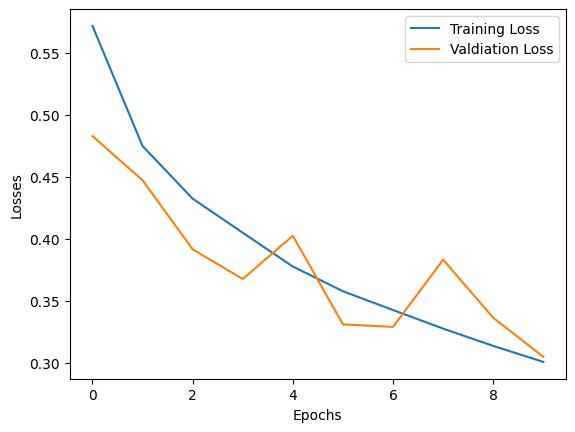

In [10]:
loss_df = pd.DataFrame({
    "Training Loss": train_losses,
    "Valdiation Loss": val_losses
})

plt.plot(loss_df["Training Loss"], label = "Training Loss")
plt.plot(loss_df["Valdiation Loss"], label = "Valdiation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()

plt.savefig("catdog_train_val_plot.png", dpi=300, bbox_inches="tight") 

In [11]:
class_names = test_dataset.classes
print(class_names)

['cat', 'dog']


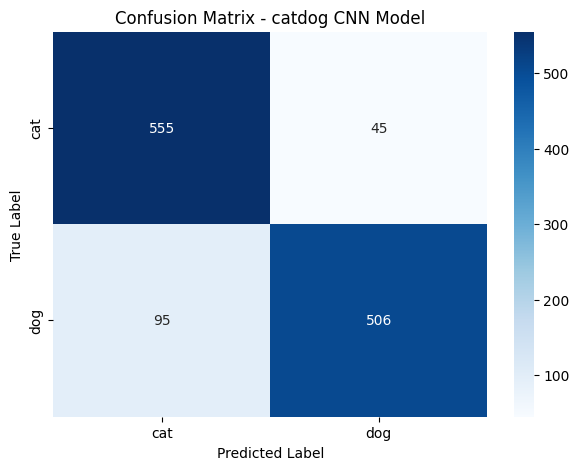

In [12]:
cm = confusion_matrix(all_actual, all_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - catdog CNN Model")
plt.savefig("catdog_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [13]:
print(classification_report(all_actual, all_pred))

              precision    recall  f1-score   support

           0       0.85      0.93      0.89       600
           1       0.92      0.84      0.88       601

    accuracy                           0.88      1201
   macro avg       0.89      0.88      0.88      1201
weighted avg       0.89      0.88      0.88      1201



In [14]:
class_names = test_dataset.classes
print(class_names)

preds_ = [class_names[i] for i in all_pred]
actul_ = [class_names[i] for i in all_actual]

['cat', 'dog']


In [15]:
preds = pd.DataFrame(preds_, columns=['predicted'])
actul = pd.DataFrame(actul_, columns=['actual'])

pd.concat([preds, actul], axis=1)

,predicted,actual
0,cat,cat
1,cat,cat
2,dog,cat
3,cat,cat
4,cat,cat
...,...,...
1196,cat,dog
1197,cat,dog
1198,dog,dog
1199,dog,dog
